<a href="https://colab.research.google.com/github/rojasperezkeiner50-a11y/lectura-de-archivo-del-profesor-/blob/main/NotebookBase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="http://www.sena.edu.co/Paginas/btl/assets_btl/images_btl/SVG/Logo%20SENA.svg" width="240" height="240" align="right"/>

<center><h1>PRODEMIA</header1></center>
<left><h1>Actividad 1. Laboratorio: Tratamiento y limpieza de datos</header1></left>

Presentado por: Nombres Apellidos  <br>
Fecha: DD/MM/2026

## Importación de librerias necesarias

In [1]:
#Para esta actividad se importarán las siguientes librerías:
import pandas as pd

## Cargar el Dataset

In [2]:
#Código para cargar el Dataset
url = 'https://raw.githubusercontent.com/hmedrano1979/ITC/refs/heads/main/dataset_clientes_ventas_con_problemas.csv'

# Leemos el archivo CSV directamente desde la URL
df = pd.read_csv(url)

# Mostramos las primeras filas para verificar
df.head()

,id,nombre_cliente,ciudad,monto_compra,fecha_compra,ticket,sexo
0,1,Juana,barranquilla,4500,01/02/2023,PC 17599,MALE
1,2,Pedro,bquilla,"2.500,75",10-04-2023 08:30:00,PC 17599,Female
2,3,JUAN,cartagena de indias,NaN,2023/03/05,PC 17599,female
3,4,Juana,Barranquilla,"2.500,75",2023-01-01,PC 17599,MALE
4,5,María,BARRANQUILLA,4500,10-04-2023 08:30:00,S.O.C. 14879,female


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              630 non-null    int64 
 1   nombre_cliente  630 non-null    object
 2   ciudad          603 non-null    object
 3   monto_compra    499 non-null    object
 4   fecha_compra    630 non-null    object
 5   ticket          630 non-null    object
 6   sexo            630 non-null    object
dtypes: int64(1), object(6)
memory usage: 34.6+ KB


## **Tratamiento de la columna SEXO**

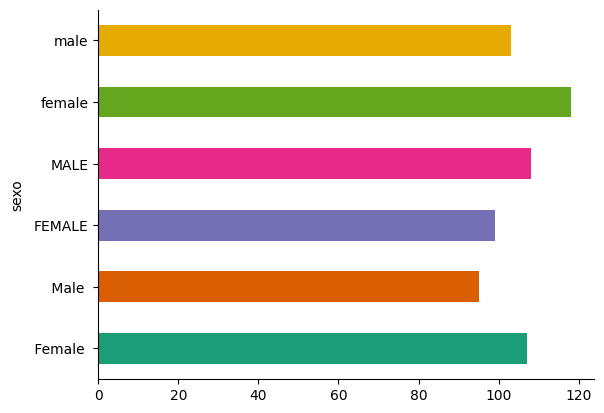

In [4]:
from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('sexo').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [5]:
df['sexo']= df['sexo'].str.lower()


In [6]:
df['sexo'].unique()

array(['male', ' female ', 'female', ' male '], dtype=object)

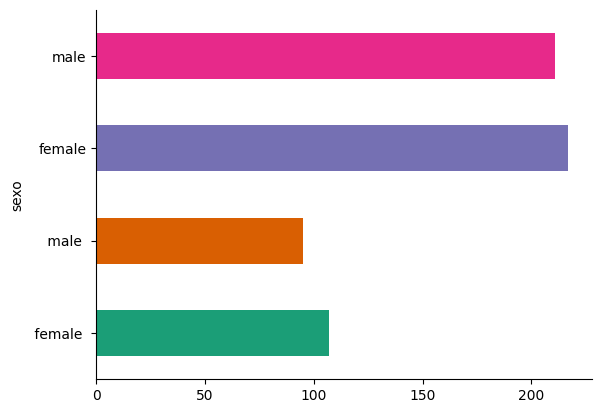

In [7]:
from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('sexo').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [8]:
df['sexo'] = df['sexo'].str.lower().str.strip()

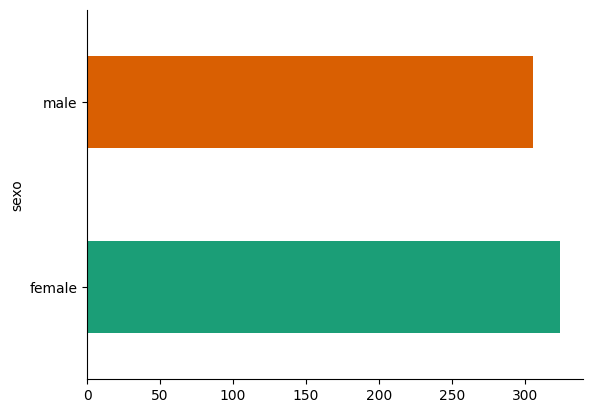

In [9]:
from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('sexo').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [10]:
df['sexo'].unique()

array(['male', 'female'], dtype=object)

In [11]:
df['sexo']=df['sexo'].astype("category")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   id              630 non-null    int64   
 1   nombre_cliente  630 non-null    object  
 2   ciudad          603 non-null    object  
 3   monto_compra    499 non-null    object  
 4   fecha_compra    630 non-null    object  
 5   ticket          630 non-null    object  
 6   sexo            630 non-null    category
dtypes: category(1), int64(1), object(5)
memory usage: 30.4+ KB


In [12]:
print(df.columns.tolist())

['id', 'nombre_cliente', 'ciudad', 'monto_compra', 'fecha_compra', 'ticket', 'sexo']


# =====================================================
#  Limpieza básica + normalización semántica de nombres
# =====================================================

In [13]:
df['nombre_cliente_clean'] = (
    df['nombre_cliente']
    .astype(str)
    .str.strip()
    .str.lower()
)

df[['nombre_cliente', 'nombre_cliente_clean']].head(10)

,nombre_cliente,nombre_cliente_clean
0,Juana,juana
1,Pedro,pedro
2,JUAN,juan
3,Juana,juana
4,María,maría
5,MARÍA,maría
6,JUAN,juan
7,JUAN,juan
8,Juana,juana
9,Carlos,carlos


## **Tratamiento de la columna CIUDAD**

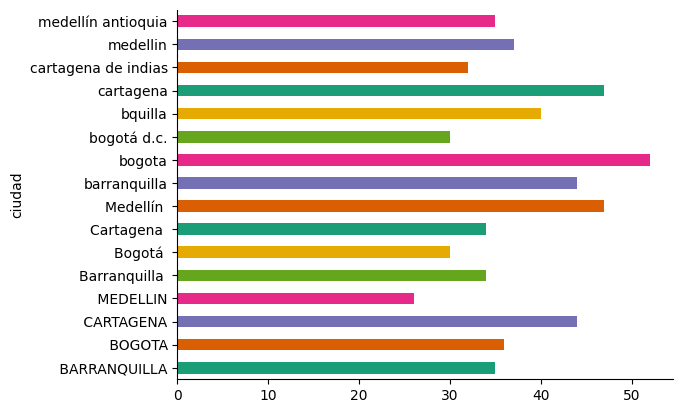

In [14]:
from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('ciudad').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [15]:
df['ciudad'] = df['ciudad'].str.lower().str.strip()

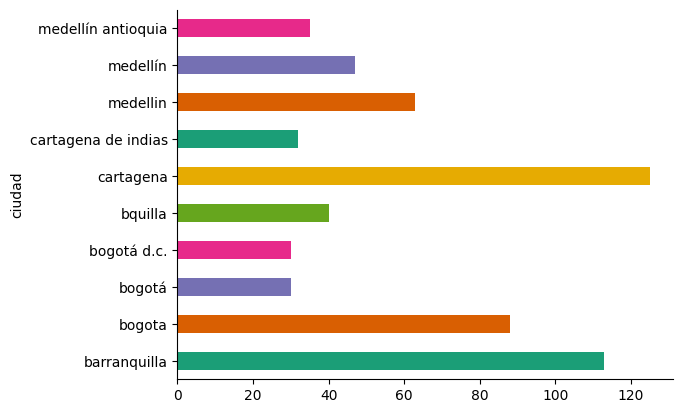

In [16]:
from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('ciudad').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [17]:
df['ciudad']= df['ciudad'].replace('medellín antioquia','medellín')

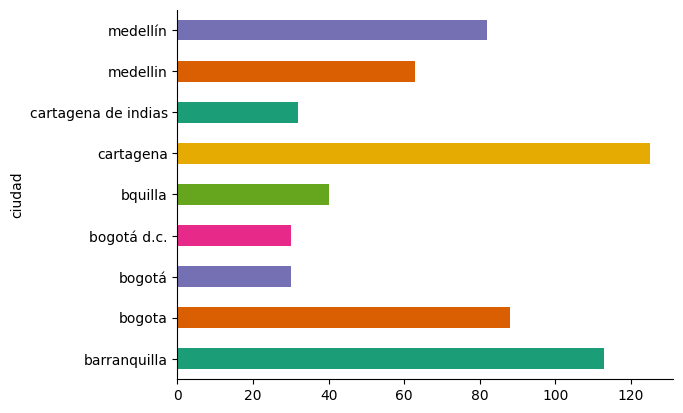

In [18]:
from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('ciudad').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [19]:
# Despues de usar el comando "unique" para visualizar los valores unicos de una columna podermos observar los valores a cambiar

# =====================================================
#  Limpieza básica + normalización semántica de ciudades
# =====================================================

# 1. Creación de una columna nueva para no perder la información original
# Aplicamos una cadena de métodos para normalizar el formato de texto
df['ciudad_clean'] = (
    df['ciudad']
        .astype(str)                   # Asegura que todo sea tratado como texto (evita errores con nulos)
        .str.strip()                   # Elimina espacios en blanco al inicio y al final (" bogota " -> "bogota")
        .str.lower()                   # Convierte todo a minúsculas para estandarizar comparaciones
        .str.replace(r"\s+", " ", regex=True) # Reemplaza múltiples espacios internos por uno solo usando Regex
)

# 2. Diccionario de normalización avanzada
# Este mapa actúa como un "traductor" de variaciones a nombres oficiales
map_ciudades = {
    # Barranquilla: Agrupamos siglas y errores comunes
    'bquilla': 'barranquilla',
    'barraquilla': 'barranquilla',
    'barrqnquilla': 'barranquilla',

    # Cartagena: Estandarizamos abreviaturas y nombres largos
    'cartagena de indias': 'cartagena',
    'ctg': 'cartagena',
    'ctg.': 'cartagena',

    # Bogotá: Unificamos variaciones con tildes, puntos y siglas "D.C."
    'bogota d.c.': 'bogota',
    'bogotá d.c.': 'bogota',
    'bogota, d.c.': 'bogota',
    'bogota dc': 'bogota',
    'bogotá': 'bogota',
    'bogota': 'bogota',

    # Medellín: Corregimos errores de codificación (caracteres extraños) y redundancias
    'medellin': 'medellín',
    'medellí­n': 'medellín',
    'medellín antioquia': 'medellín'
}

# 3. Aplicar los reemplazos definidos en el diccionario
# El método .replace() busca las llaves y las cambia por sus valores correspondientes
df['ciudad_clean'] = df['ciudad_clean'].replace(map_ciudades)

# 4. Verificación de resultados
# Comparamos la columna original con la limpia para validar la efectividad
print("--- Comparativa de Normalización ---")
print(df[['ciudad', 'ciudad_clean']].head(10))

# 5. Validación de la Caracterización Final
# Revisamos cuántas categorías únicas quedaron después de la limpieza
print("\n--- Estadísticas Finales ---")
print(f"Ciudades únicas originales: {df['ciudad'].nunique()}")
print(f"Ciudades únicas limpias: {df['ciudad_clean'].nunique()}")
print("\nConteos por ciudad:")
print(df['ciudad_clean'].value_counts())

--- Comparativa de Normalización ---
                ciudad  ciudad_clean
0         barranquilla  barranquilla
1              bquilla  barranquilla
2  cartagena de indias     cartagena
3         barranquilla  barranquilla
4         barranquilla  barranquilla
5            cartagena     cartagena
6               bogota        bogota
7          bogotá d.c.        bogota
8  cartagena de indias     cartagena
9              bquilla  barranquilla

--- Estadísticas Finales ---
Ciudades únicas originales: 9
Ciudades únicas limpias: 5

Conteos por ciudad:
ciudad_clean
cartagena       157
barranquilla    153
bogota          148
medellín        145
nan              27
Name: count, dtype: int64


# ==========================================================
#  Limpieza Pro: Normalización de Texto y Gestión de Nulos
# ==========================================================

**Ejemplo visual del proceso**
Imagina que procesamos la palabra "Bogotá":  


Entrada: "Bogotá"

Normalización (NFD): Se convierte internamente en ['B', 'o', 'g', 'o', 't', 'a', '´']. El acento ahora es un objeto independiente.

Identificación de Categoría:

B, o, g, o, t, a son categorizados como "L" (Letras).

´ es categorizado como "Mn" (Mark, Nonspacing / Marca sin espacio).

Filtro: La función dice: "Pasa la B, pasa la o... pero el acento 'Mn' se queda fuera".

Resultado: "Bogota"


--------------------------------------



**¿Por qué es mejor que usar .replace('á', 'a')?**
Si usas .replace(), tendrías que hacer uno por cada vocal, mayúsculas, minúsculas y caracteres especiales como la ñ (si también quisieras convertirla en n) o la ü.

La función con unicodedata:

Es universal: Funciona para cualquier acento o diéresis de cualquier idioma.

Es eficiente: Procesa todo el texto de una sola pasada.

Es limpia: Reduce drásticamente las reglas manuales que tienes que escribir.

Dato curioso: Esta técnica se usa mucho en buscadores (como Google) para que, si buscas "pajaro" sin tilde, encuentres resultados que digan "pájaro".

In [20]:
import unicodedata
#Tenemos la mejora del codigo anterior agregando una funcion auxiliar "eliminar_tildes" que elimina las tildes y le permite manejar los campos nulos con desconocido
# ==========================================================
#  Limpieza Pro: Normalización de Texto y Gestión de Nulos
# ==========================================================

def eliminar_tildes(texto):
    # SEGURIDAD: Si el dato es nulo (NaN) o no es texto, devuélvelo tal cual
    # para evitar que el código "explote".
    if pd.isna(texto) or not isinstance(texto, str):
        return texto

    # NORMALIZACIÓN (NFD): Descompone "é" en "e" + "´"
    # La 'e' es un carácter base y el '´' es una "marca de combinación" (Mn).
    normalizado = unicodedata.normalize('NFD', texto)

    # FILTRADO: Recorremos cada carácter y solo guardamos los que NO sean marcas de acento.
    # unicodedata.category(c) != 'Mn' significa: "Si no es una marca de acento, guárdalo".
    return "".join(c for c in normalizado if unicodedata.category(c) != 'Mn')


# 1. Preparación inicial y limpieza de espacios/nulos
# Reemplazamos nulos por un valor estándar para evitar errores en el procesamiento
df['ciudad'] = df['ciudad'].fillna('desconocido')

# 2. Aplicación de limpieza técnica en cadena
df['ciudad_clean'] = (
    df['ciudad']
        .astype(str)
        .str.lower()    # Primero minúsculas
        .apply(eliminar_tildes) # <--- Nueva función aplicada quitamos acentos
        # ELIMINAR CARACTERES ESPECIALES:
        # Mantiene solo letras de la 'a' a la 'z' y espacios (\s).
        # Borra puntos, comas, guiones, etc.
        .str.replace(r"[^a-z\s]", "", regex=True) # Quitamos símbolos/puntos
        .str.replace(r"\s+", " ", regex=True)    # Colapsamos espacios múltiples
        .str.strip()               # <--- ¡MUY IMPORTANTE AL FINAL!
)

df['ciudad_clean'] = (
    df['ciudad']
        .astype(str)
        .str.lower()               # Primero minúsculas
        .apply(eliminar_tildes)    # Luego quitamos acentos
        .str.replace(r"[^a-z\s]", "", regex=True) # Quitamos símbolos/puntos
        .str.replace(r"\s+", " ", regex=True)    # Colapsamos espacios múltiples
        .str.strip()               # <--- ¡MUY IMPORTANTE AL FINAL!
)





# 3. Diccionario de normalización semántica (AHORA MÁS CORTO)
# Ya no necesitamos variantes con tildes (como "bogotá"), la función ya las limpió.
map_ciudades = {
    'bquilla': 'barranquilla',
    'barraquilla': 'barranquilla',
    'barrqnquilla': 'barranquilla',
    'cartagena de indias': 'cartagena',
    'ctg': 'cartagena',
    'ctg.': 'cartagena',
    'bogota d.c.': 'bogota',
    'bogota, d.c.': 'bogota',
    'bogota dc': 'bogota',
    'medellin antioquia': 'medellin'
    # Medellín ahora se unifica simplemente en 'medellin' sin tilde
}

# 4. Aplicar reemplazos finales
df['ciudad_clean'] = df['ciudad_clean'].replace(map_ciudades)

# 5. Reporte de Caracterización Post-Limpieza
print("=== RESUMEN DE CARACTERIZACIÓN ===")
n_original = df['ciudad'].nunique()
n_limpio = df['ciudad_clean'].nunique()
reduccion = n_original - n_limpio

print(f"Ciudades únicas antes: {n_original}")
print(f"Ciudades únicas ahora: {n_limpio}")
print(f"Se consolidaron {reduccion} variantes de nombres.")
print("-" * 34)
print(df['ciudad_clean'].value_counts().head(10))

=== RESUMEN DE CARACTERIZACIÓN ===
Ciudades únicas antes: 10
Ciudades únicas ahora: 5
Se consolidaron 5 variantes de nombres.
----------------------------------
ciudad_clean
cartagena       157
barranquilla    153
bogota          148
medellin        145
desconocido      27
Name: count, dtype: int64


**¿Cómo funciona el Regex [^a-z\s]?**
Es una expresión regular de "exclusión":

[]: Define un grupo de caracteres.

^: Dentro de los corchetes, significa "todo lo que NO sea".

a-z: Letras minúsculas.

\s: Espacios en blanco.

Resultado: Si el texto es "bogota, d.c.", el regex detecta la , y los . como elementos prohibidos y los elimina, dejando "bogota dc".

**Visualización de la Caracterización**
Para cerrar con broche de oro la caracterización de esta variable, lo ideal es ver la distribución. Los datos limpios se aprecian mejor en un gráfico.

/tmp/ipython-input-629702101.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='ciudad_clean', order=df['ciudad_clean'].value_counts().index, palette='viridis')


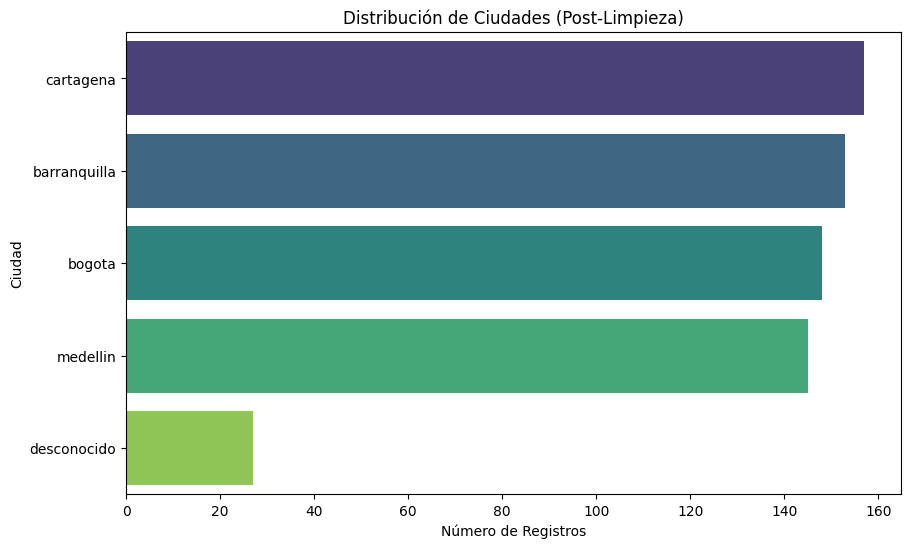

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='ciudad_clean', order=df['ciudad_clean'].value_counts().index, palette='viridis')
plt.title('Distribución de Ciudades (Post-Limpieza)')
plt.xlabel('Número de Registros')
plt.ylabel('Ciudad')
plt.show()

**¿Cuál elegir?**
### ¿Cuál elegir para la caracterización?

| Si buscas... | Usa esta Librería... | Fortalezas Principales |
| :--- | :--- | :--- |
| **Detectar errores técnicos** | `YData Profiling` | Análisis profundo de nulos, duplicados y alertas de calidad. |
| **Presentar a clientes/jefes** | `Sweetviz` | Gráficos estéticos, limpios y comparativos (Target vs Características). |
| **Limpiar datos interactivamente** | `D-Tale` | Interfaz tipo "Excel con esteroides" que permite filtrar y generar código. |

**YData Profiling (El estándar de la industria)**

Análisis Exhaustivo con YData Profiling
Esta librería genera un informe técnico completo. Es ideal para detectar:

Correlaciones: Relaciones lineales y no lineales entre variables.

Alertas: Variables con muchos ceros, alta cardinalidad o valores faltantes.

Interacciones: Gráficos de dispersión automáticos entre pares de variables.

In [22]:
# Instala la librería si no la tienes:
!pip install ydata-profiling
from ydata_profiling import ProfileReport

# 1. Creamos el objeto del reporte
# 'explorative=True' añade análisis extra como histogramas detallados
reporte_completo = ProfileReport(df, title="Análisis de Datos Inicial", explorative=True)

# 2. Generar el archivo físico (HTML)
# Esto crea un archivo en tu carpeta de trabajo que puedes abrir en cualquier navegador
reporte_completo.to_file("resumen_ydata.html")

# 3. Si estás en un Notebook, puedes visualizarlo directamente en la celda:
# reporte_completo.to_jupyter()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.7 MB/s eta 0:00:00


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:00<00:00, 46.81it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

**Sweetviz (Visualización Comparativa)**

Análisis Visual con Sweetviz
Sweetviz se destaca por su estética y su capacidad de comparación. Es perfecto cuando quieres ver cómo se distribuyen los datos respecto a una variable objetivo (Target), por ejemplo: ¿Cómo varían los ingresos según el sexo?

In [23]:
# Instala la librería si no la tienes: !pip install sweetviz
import sweetviz as sv

# 1. Generamos el reporte analizando el DataFrame
# 'target_feat' nos permite elegir una variable central para comparar el resto
reporte_visual = sv.analyze(df, target_feat='ciudad_clean')

# 2. Creamos el archivo HTML
# 'open_browser=True' lo abrirá automáticamente en una pestaña nueva
reporte_visual.show_html("resumen_sweetviz.html")

ModuleNotFoundError: No module named 'sweetviz'

**D-Tale (Exploración Interactiva)**

Exploración Estilo Hoja de Cálculo con D-Tale
A diferencia de los anteriores, D-Tale no es un reporte estático. Abre una interfaz viva que te permite:

Filtrar datos como en Excel.

Ver gráficos de correlación dinámicos.

Realizar transformaciones de datos y copiar el código Python resultante.

In [ ]:
# Instala la librería si no la tienes: !pip install dtale
import dtale

# 1. Lanzamos el visualizador interactivo
# Se abrirá una dirección local (ej. http://localhost:40000)
instancia_dtale = dtale.show(df)

# 2. Abrir automáticamente en el navegador predeterminado
instancia_dtale.open_browser()

# Nota: Para detener la instancia si consume mucha memoria:
# instancia_dtale.kill()

# Métodos de limpieza

**Es importante saber qué herramienta usar según el caso:**

.str.strip(): Elimina espacios al inicio y al final (el más usado).

.str.lstrip(): Elimina espacios solo a la izquierda.

.str.rstrip(): Elimina espacios solo a la derecha.

.str.replace(" ", ""): Elimina todos los espacios, incluso los que están en medio de las palabras.

**Encadenar métodos**
**Puedes aplicar la conversión a minúsculas y la eliminación de espacios en una sola línea:**

In [ ]:
# .strip() elimina espacios al inicio y al final
df['sexo'] = df['sexo'].str.lower().str.strip()

# Verificamos el resultado
print(df['sexo'].unique())

**¿Cómo detectar el problema visualmente?**
A veces, al imprimir los datos, los espacios no se notan. Una técnica útil para "ver" esos espacios antes de limpiar es rodear los valores con un carácter especial al visualizarlos:

In [ ]:
# Ver los valores únicos con pipes (|) para detectar espacios
print([f"|{x}|" for x in df['sexo'].unique()])

# Ejemplo de salida antes de limpiar: ["| hombre|", "|hombre|", "|mujer |"]
# Ejemplo de salida después de limpiar: ["|hombre|", "|mujer|"]

**Tip Pro: Limpiar todo el dataset de una vez**
Si sospechas que muchas columnas tienen este problema de espacios, no necesitas ir una por una. Puedes aplicar una limpieza general a todas las columnas de texto (tipo object):

In [ ]:
# Selecciona solo las columnas de texto y aplica strip
df_obj = df.select_dtypes(['category'])|df.select_dtypes(['object'])
df[df_obj.columns] = df_obj.apply(lambda x: x.str.strip())
df.head()

## Caracterización del Dataset

Se incluye una descripción de los datos.

En esta etapa buscamos identificar:

>- Tipos de datos incorrectos  
>- Patrones de valores faltantes  
>- Duplicados  
>- Columnas que requieren estandarización  
>- Posibles conversiones necesarias  

**Analogía:**  
Es como un médico que evalúa a un paciente antes de recetar tratamiento.

Se incorporá una descripción (EDA) del conjunto de datos utilizado. Se analiza el dataset proporcionando, se muestra al menos algunas de sus características mediante tablas y al menos algunas de ellas en modo gráfico (p.ej., histogramas, diagramas de dispersión, diagramas de cajas y bigotes, etc.)

## Explique el problema a resolver.
Descripción del problema. Tipo de problema (justifique). Utilidad de su posible solución. Elementos adicionales que considere relevantes:

En un par de párrafos haga un resumen de los principales hallazagos encontrados:    

In [ ]:
#Código que responde a la descripción anterior

In [ ]:
#Código que responde a la descripción anterior (incorpore las lineas de code necesarias. Describa cadas sentencia de código)

Construya un párrafo con los principales hallazgos.

## Preprocesamiento del dataset. Transformaciones previas necesarias.

Construya un párrafo con los principales hallazgos.

In [ ]:
#Código que realice las transformaciones necesarias para poder realizar los procesos de modelación. Ej.One hot enconding

## Discusión de los resultados obtenidos y argumentos sobre cómo se podrían mejorar de dichos resultados

Realice en este espacio todo el análsis de resultados final incluyendo: ventajas y desventajas de cada modelo propuesto, Resultados comparados. Conclusiones objetivas y significantes con base a las diferentes métricas escogidas. Recomendaciones de mejora de las propuestas: